#   On compare PDF(s) et PDF(T) pour les 3 conditions de bords

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '../Fct_scripts')))
from tools import *
from macro import macros

L1 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD5n1")[0]
L2 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD5n1")[1]

lengthtab = L1 * L2
nbins = 100
Tnmin = np.array([5,8, 8,8,7,7,7, 8,8,8,8, 8, 8, 8,8])
Tnmax = np.array([80,45,50,50,50,50,50, 80,80,80,80,80,80,80])
fnb = np.arange(1,14)

folderpath_open = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
folderpath_per = [f'/data1/DATA_Duplat/Brut/PDF/PD1n{nb}' for nb in fnb]
folderpath_ref = [f'/data1/DATA_Duplat/Brut/PDF/PD6n{nb}' for nb in fnb]

Tvar = [read_parameters(folder)[2] for folder in folderpath_open]

##  Size

In [2]:
def process_size(folder, Lengthtab, nmin, nmax):
    data = np.loadtxt(f"{folder}/stat_histosize.txt", comments = "#")
    
    last_non_zero = np.nonzero(data)[0]
    
    nbins = freedman_diaconis_log_bins(data)
    
    mean = np.sum(data * np.arange(len(data)))/np.sum(data)
    
    ndatafit, ndistloglog, nstat = mainfct(data, Lengthtab, nbins, nmin, nmax)
    Tndist = 10 ** ndistloglog
    Tndatafit = 10 ** ndatafit
    Tnstat = nstat[0]
    
    return Tndist, Tndatafit, Tnstat, last_non_zero[-1], mean, nbins


def fct_plot (dist, start_x, stop_x, ax, n_curves, color, label):
    
    Ttau = np.zeros(n_curves)
    Tperr = np.zeros(n_curves)
    for j in range(n_curves):

        mask = dist[j][:,1] != 1
        filt_dist = dist[j][mask]

        if Tvar[j] == 0.0:
            result, xs, _ , perr = fit_powerlaw(filt_dist[:,0], filt_dist[:,1], stop_x = stop_x[j], start_x = start_x[j], switch = 1,  plot=True, f_scale=1.0,
                                        function_to_fit='power')
        else:
            result, xs, _ , perr = fit_powerlaw(filt_dist[:,0], filt_dist[:,1], n_cutoff = stop_x[j], start_x = start_x[j], plot=True, f_scale=1.0,
                                        function_to_fit='power')
        Ttau[j] = np.round(result.x[1], 3)
        Tperr[j] =  np.round(perr[1], 3)

        
    ax.errorbar(Tvar, - Ttau, yerr = Tperr, fmt = '-o', color = color, lw =2, markersize = 10, label = label)
    # ax.plot(Tvar, -Ttau, linestyle = '-', c = 'k', zorder=1)

    

In [3]:
results_open = Parallel(n_jobs=-1)(delayed(process_size)(folder, lengthtab, nmin, nmax)
                                  for (folder, nmin, nmax) in zip(folderpath_open, Tnmin, Tnmax))


In [4]:

results_per = Parallel(n_jobs=-1)(delayed(process_size)(folder, lengthtab, nmin, nmax)
                                  for (folder, nmin, nmax) in zip(folderpath_per, Tnmin, Tnmax))

In [5]:

results_ref = Parallel(n_jobs=-1)(delayed(process_size)(folder, lengthtab, nmin, nmax)
                                  for (folder, nmin, nmax) in zip(folderpath_ref, Tnmin, Tnmax))

In [6]:
dist_open, datafit_open, stats_open, nonzero_open, means_open, bins_open = map(np.array, zip(*results_open))
dist_per, datafit_per, stats_per, nonzero_per, means_per, bins_per = map(np.array, zip(*results_per))
dist_ref, datafit_ref, stats_ref, nonzero_ref, means_ref, bins_ref = map(np.array, zip(*results_ref))

<ipython-input-6-ee301f9f7166>:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  dist_open, datafit_open, stats_open, nonzero_open, means_open, bins_open = map(np.array, zip(*results_open))
<ipython-input-6-ee301f9f7166>:2: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  dist_per, datafit_per, stats_per, nonzero_per, means_per, bins_per = map(np.array, zip(*results_per))
<ipython-input-6-ee301f9f7166>:3: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different len

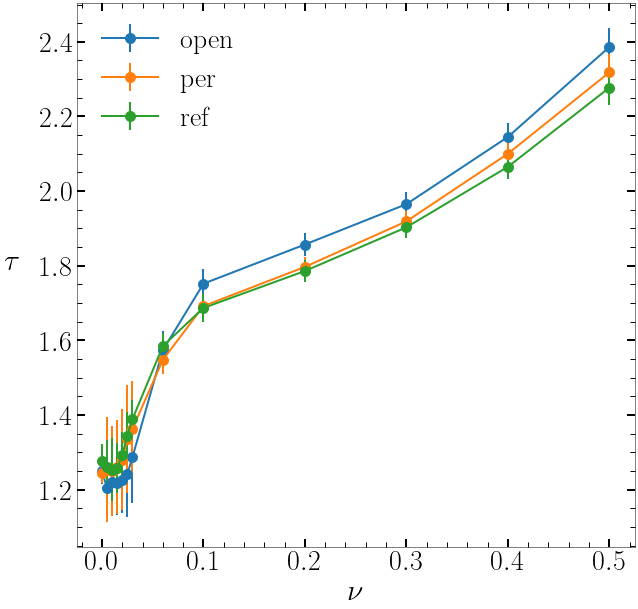

In [7]:
stop_open = [2.5e4, 1e-8, 1e-10, 1e-8, 1e-6,5e-5,5e-5,1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-11, 1e-12]
start_open = [1,1,0,1,1,0,1,2,4,4,4,8,8,8,8]

stop_per = [5e4,3e-5,3e-5,3e-5,4e-5,5e-5,5e-5,1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-11, 1e-12]
start_per = [2,4,2,2,2,2,1,2,4,4,4,8,8,8,8]

stop_ref = [5e3, 1e-5, 2e-5, 6e-6, 3e-6, 3e-6, 1e-6, 2e-7, 1e-7, 3e-9, 1e-10, 1e-11, 1e-11, 1e-12]
start_ref = [1,1,1,1,1,1,1,2,4,4,4,8,8,8,8]

NCURVES = len(dist_open)
fig, ax = plt.subplots(figsize=(10,10))

fct_plot(dist_open, start_open, stop_open, ax, NCURVES, color = 'tab:blue', label = 'open')
fct_plot(dist_per, start_per, stop_per, ax, NCURVES, color = 'tab:orange', label = 'per')
fct_plot(dist_ref, start_ref, stop_ref, ax, NCURVES, color = 'tab:green', label = 'ref')

ax.set_xlabel(r'$\nu$', fontsize=30)
ax.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax.tick_params(labelsize = 28,length = 8, width = 2)
ax.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax.legend(fontsize = 28)

plt.show()

##  Intertime

In [8]:
def process_time(folder, nbins):
    histo = np.loadtxt(f"{folder}/stat_histoitime.txt", comments = "#")
    bins = np.logspace(np.log10(10**-12), np.log10(2), nbins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean = np.sum(histo * bin_centers) / np.sum(histo)
    
    norm_histo = histo/((np.diff(bins)) * histo.sum())
    norm_histo = norm_histo * mean
    
    norm_bin_centers = bin_centers/mean

    return norm_bin_centers, norm_histo
    
def fct_plot_intertime(histo, bins, n_curves, stop_x, start_x, ax, color, label, red_nbins = 100):
    
    Tgamma = np.zeros(n_curves)
    Tperr = np.zeros(n_curves)
    
    for j in range(n_curves):
    
        bins_reduced, histo_reduced_norm = change_bins_log_histo(bins[j], histo[j], red_nbins)
        mask = histo_reduced_norm!=0
        
        result, xs, _ , perr = fit_powerlaw(bins_reduced[:-1][mask], histo_reduced_norm[mask], stop_x = stop_x[j], start_x = start_x[j], f_scale=1.0,
                                    function_to_fit='power', switch = 1)


        Tgamma[j] = np.round(result.x[1], 3)
        Tperr[j] =  np.round(perr[1], 3)

    ax.errorbar(Tvar, - Tgamma, yerr = Tperr, fmt = '-o', color = color, lw =2, markersize = 10, label = label)
    # ax2.plot(Tvar, -Tgamma, linestyle = '-', c = 'k', zorder=1)
    
    

In [9]:
nbins = 1000
it_results_open = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins + 1)
                                  for folder in folderpath_open)

In [10]:
it_results_per = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins + 1)
                                  for folder in folderpath_per)

In [11]:
it_results_ref = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins + 1)
                                  for folder in folderpath_ref)

In [12]:
bin_centers_open, histo_open = map(np.array, zip(*it_results_open))
bin_centers_per, histo_per = map(np.array, zip(*it_results_per))
bin_centers_ref, histo_ref = map(np.array, zip(*it_results_ref))


In [13]:
stop_x_open = [1e-1,1e-1,1e-1,1e-1,1e-1,
        1e-1,1e-5,1e-5,4e-4,5e-3,
        5e-2,5e-2,5e-2,5e-2]

start_x_open = [1e-6,1e-10,1e-6,1e-10,1e-7,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

stop_x_per = [1e-1,1e-1,1e-1,1e-6,5e-6,
        1e-5,1e-5,1e-5,4e-4,5e-3,
        5e-2,5e-2,5e-2,5e-2]

start_x_per = [1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

stop_x_ref = [1e-1,1e-1,1e-5,1e-5,1e-5,
        1e-5,1e-4,1e-3,1e-3,1e-2,
        5e-2,5e-2,5e-2,5e-2]

start_x_ref = [1e-5,1e-5,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

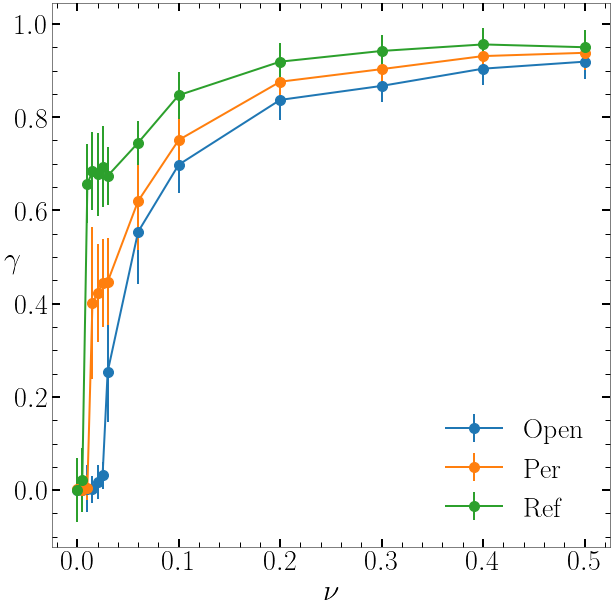

In [14]:
NCURVES = len(histo_open)
fig, ax = plt.subplots(figsize=(10, 10))

fct_plot_intertime(histo_open, bin_centers_open, NCURVES, stop_x_open, start_x_open, ax, 'tab:blue', 'Open')
fct_plot_intertime(histo_per, bin_centers_per, NCURVES, stop_x_per, start_x_per, ax, 'tab:orange', 'Per')
fct_plot_intertime(histo_ref, bin_centers_ref, NCURVES, stop_x_ref, start_x_ref, ax, 'tab:green', 'Ref')

ax.set_xlabel(r'$\nu$', fontsize = 30)
ax.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax.tick_params(labelsize = 28,length = 8, width = 2)
ax.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax.legend(fontsize = 28)
plt.show()

### Essayons de regarder que les avalanches de taille supérieur ou égale à 2

In [15]:
def process_time2(folder, nbins):
    histo = np.loadtxt(f"{folder}/stat_histoitime2.txt", comments = "#")
    bins = np.logspace(np.log10(10**-12), np.log10(2), nbins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean = np.sum(histo * bin_centers) / np.sum(histo)
    
    norm_histo = histo/((np.diff(bins)) * histo.sum())
    norm_histo = norm_histo * mean
    
    norm_bin_centers = bin_centers/mean

    return norm_bin_centers, norm_histo
    
def fct_plot_intertime(histo, bins, n_curves, stop_x, start_x, ax, color, label, red_nbins = 100):
    
    Tgamma = np.zeros(n_curves)
    Tperr = np.zeros(n_curves)
    
    for j in range(n_curves):
    
        bins_reduced, histo_reduced_norm = change_bins_log_histo(bins[j], histo[j], red_nbins)
        mask = histo_reduced_norm!=0
        
        result, xs, _ , perr = fit_powerlaw(bins_reduced[:-1][mask], histo_reduced_norm[mask], stop_x = stop_x[j], start_x = start_x[j], f_scale=1.0,
                                    function_to_fit='power', switch = 1)


        Tgamma[j] = np.round(result.x[1], 3)
        Tperr[j] =  np.round(perr[1], 3)

    ax.errorbar(Tvar, - Tgamma, yerr = Tperr, fmt = '-o', color = color, lw =2, markersize = 10, label = label)
    # ax2.plot(Tvar, -Tgamma, linestyle = '-', c = 'k', zorder=1)
    
    

In [16]:
nbins = 1000
it_results_open = Parallel(n_jobs=-1)(delayed(process_time2)(folder, nbins + 1)
                                  for folder in folderpath_open)

In [17]:
it_results_per = Parallel(n_jobs=-1)(delayed(process_time2)(folder, nbins + 1)
                                  for folder in folderpath_per)

FileNotFoundError: /data1/DATA_Duplat/Brut/PDF/PD1n1/stat_histoitime2.txt not found.

In [18]:
it_results_ref = Parallel(n_jobs=-1)(delayed(process_time2)(folder, nbins + 1)
                                  for folder in folderpath_ref)

In [19]:
bin_centers_open, histo_open = map(np.array, zip(*it_results_open))
# bin_centers_per, histo_per = map(np.array, zip(*it_results_per))
bin_centers_ref, histo_ref = map(np.array, zip(*it_results_ref))


In [20]:
stop_x_open = [1e-1,1e-1,1e-1,1e-1,1e-1,
        1e-1,1e-5,1e-5,4e-4,5e-3,
        5e-2,5e-2,5e-2,5e-2]

start_x_open = [1e-6,1e-10,1e-6,1e-10,1e-7,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

stop_x_per = [1e-1,1e-1,1e-1,1e-6,5e-6,
        1e-5,1e-5,1e-5,4e-4,5e-3,
        5e-2,5e-2,5e-2,5e-2]

start_x_per = [1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

stop_x_ref = [1e-1,1e-1,1e-5,1e-5,1e-5,
        1e-5,1e-4,1e-3,1e-3,1e-2,
        5e-2,5e-2,5e-2,5e-2]

start_x_ref = [1e-5,1e-5,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

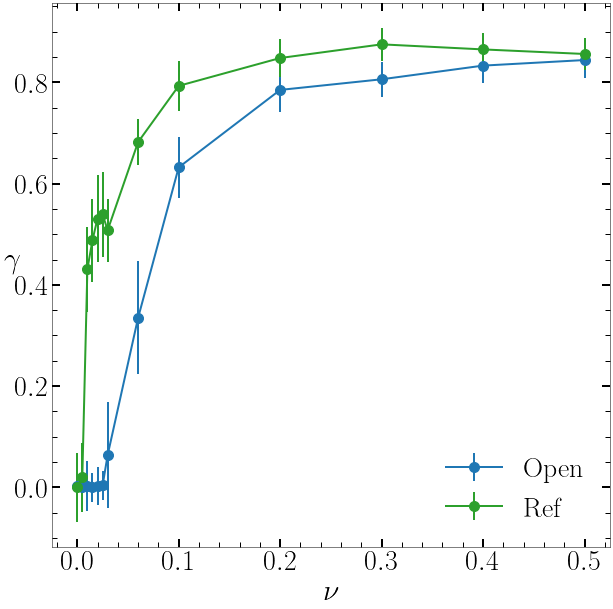

In [21]:
NCURVES = len(histo_open)
fig, ax = plt.subplots(figsize=(10, 10))

fct_plot_intertime(histo_open, bin_centers_open, NCURVES, stop_x_open, start_x_open, ax, 'tab:blue', 'Open')
# fct_plot_intertime(histo_per, bin_centers_per, NCURVES, stop_x_per, start_x_per, ax, 'tab:orange', 'Per')
fct_plot_intertime(histo_ref, bin_centers_ref, NCURVES, stop_x_ref, start_x_ref, ax, 'tab:green', 'Ref')

ax.set_xlabel(r'$\nu$', fontsize = 30)
ax.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax.tick_params(labelsize = 28,length = 8, width = 2)
ax.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax.legend(fontsize = 28)
plt.show()

Il n'y a pas de grande différence